# Demo: dataresqc-style Plotting Functions

Demonstration of the plotting functions inspired by the R package dataresqc.

In [2]:
import importlib
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Force reload to pick up any changes to plots.py
for mod_name in list(sys.modules):
    if "agrometflow" in mod_name:
        del sys.modules[mod_name]

from agrometflow.dataquality.plots import (
    plot_decimals,
    plot_daily,
    plot_subdaily,
    plot_weekly_cycle
)

%matplotlib inline


## 1. Load sample data from POWER pipeline

In [4]:
# Load POWER data if available
csv_path = Path("data/climate/power/power_19810101_20201231.csv")

if csv_path.exists():
    clim_df = pd.read_csv(csv_path)
    
    # Parse date
    if 'Date' in clim_df.columns:
        clim_df['Date'] = pd.to_datetime(clim_df['Date'], format='%Y%m%d', errors='coerce')
    
    # Show info
    print(f"Loaded {len(clim_df)} records")
    print(f"Date range: {clim_df['Date'].min()} to {clim_df['Date'].max()}")
    display(clim_df.head())
else:
    print(f"Data file not found: {csv_path}")
    print("Run the POWER pipeline first (cell 3-4 in pipeline.ipynb)")

Loaded 14610 records
Date range: 1981-01-01 00:00:00 to 2020-12-31 00:00:00


,Date,T2M,PR,TMIN,TMAX,lat,lon
0,1981-01-01,20.17,0.0,12.58,30.38,12.5,-1.2
1,1981-01-02,19.59,0.0,11.99,30.16,12.5,-1.2
2,1981-01-03,18.53,0.0,11.05,28.55,12.5,-1.2
3,1981-01-04,19.11,0.0,11.84,28.83,12.5,-1.2
4,1981-01-05,19.46,0.0,12.48,29.25,12.5,-1.2


## 2. Plot Decimals Distribution

Investigate the reporting resolution by examining the distribution of decimal digits.

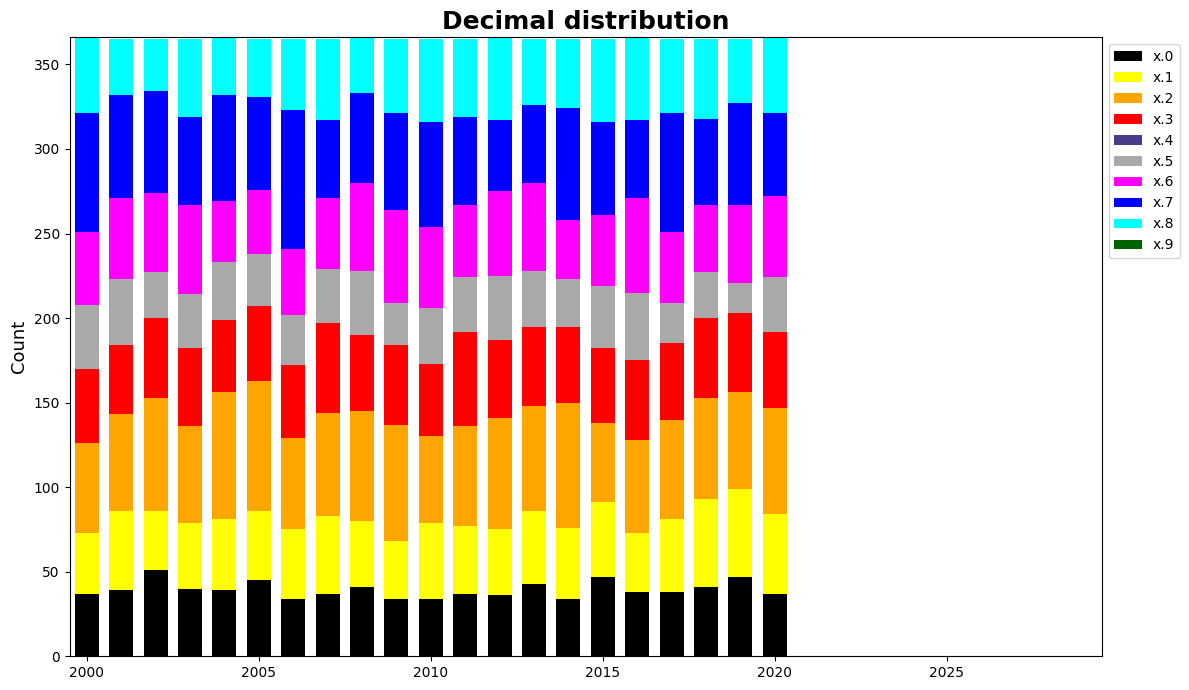

In [5]:

# Plot decimals for TMAX
if csv_path.exists() and 'TMAX' in clim_df.columns:
    plot_decimals(
        data=clim_df[['Date', 'TMAX']].rename(columns={'TMAX': 'value'}),
        date_col='Date',
        value_col='value',
        startyear=2000,
        endyear=2020,
        show=True
    )
else:
    print("Data not available")


## 3. Plot Daily Time Series

Visualize daily observations with missing data indicators.

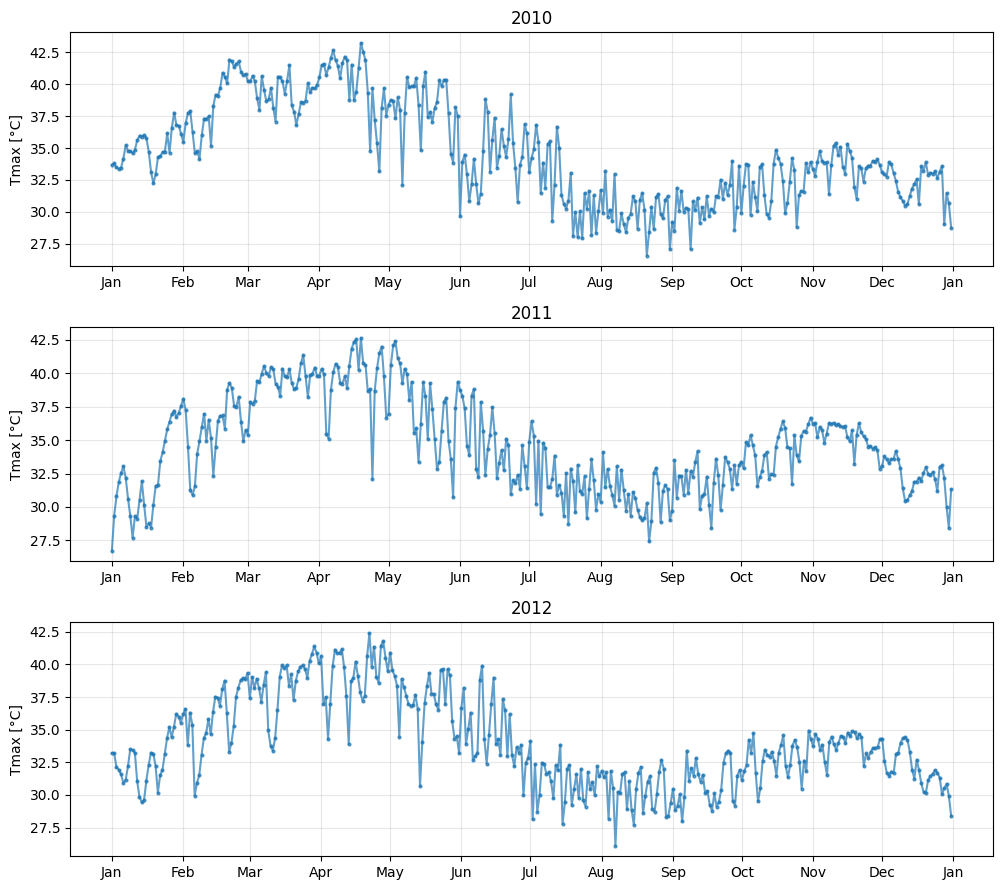

In [9]:

# Plot daily TMAX for 2010-2012
if csv_path.exists() and 'TMAX' in clim_df.columns:
    plot_daily(
        data=clim_df[['Date', 'TMAX']].rename(columns={'TMAX': 'value'}),
        date_col='Date',
        value_col='value',
        var_name='Tmax',
        units='°C',
        startyear=2010,
        endyear=2012,
        years_per_panel=1,
        show_missing=True,
        show=True,
        marker='o',
        markersize=2,
        linestyle='-',
        alpha=0.7
    )
else:
    print("Data not available")


## 4. Plot Weekly Cycle for Precipitation

Test for systematic biases in precipitation reporting by day of week.

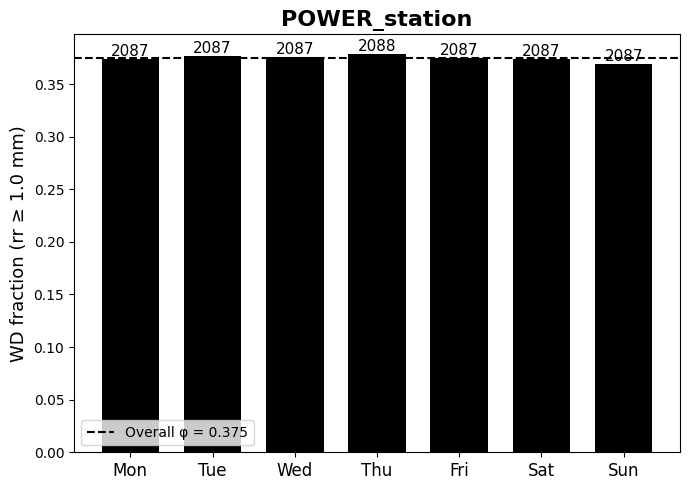


Weekly cycle test results:
Overall wet day probability: 0.375

Significant deviations:


In [10]:

# Plot weekly cycle for precipitation
if csv_path.exists() and 'PR' in clim_df.columns:
    results = plot_weekly_cycle(
        data=clim_df[['Date', 'PR']].rename(columns={'PR': 'rr'}),
        date_col='Date',
        precip_col='rr',
        station_id='POWER_station',
        threshold=1.0,
        confidence_level=0.95,
        show=True
    )
    
    print("\nWeekly cycle test results:")
    print(f"Overall wet day probability: {results['phi']:.3f}")
    print("\nSignificant deviations:")
    for wd, sig, frac in zip(results['weekdays'], results['significant'], results['fractions']):
        if sig:
            print(f"  - {wd}: {frac:.3f} ({'↑' if frac > results['phi'] else '↓'})")
else:
    print("Data not available")


## 5. Example: Create synthetic sub-daily data and plot

Demonstration of sub-daily plotting function with synthetic data.

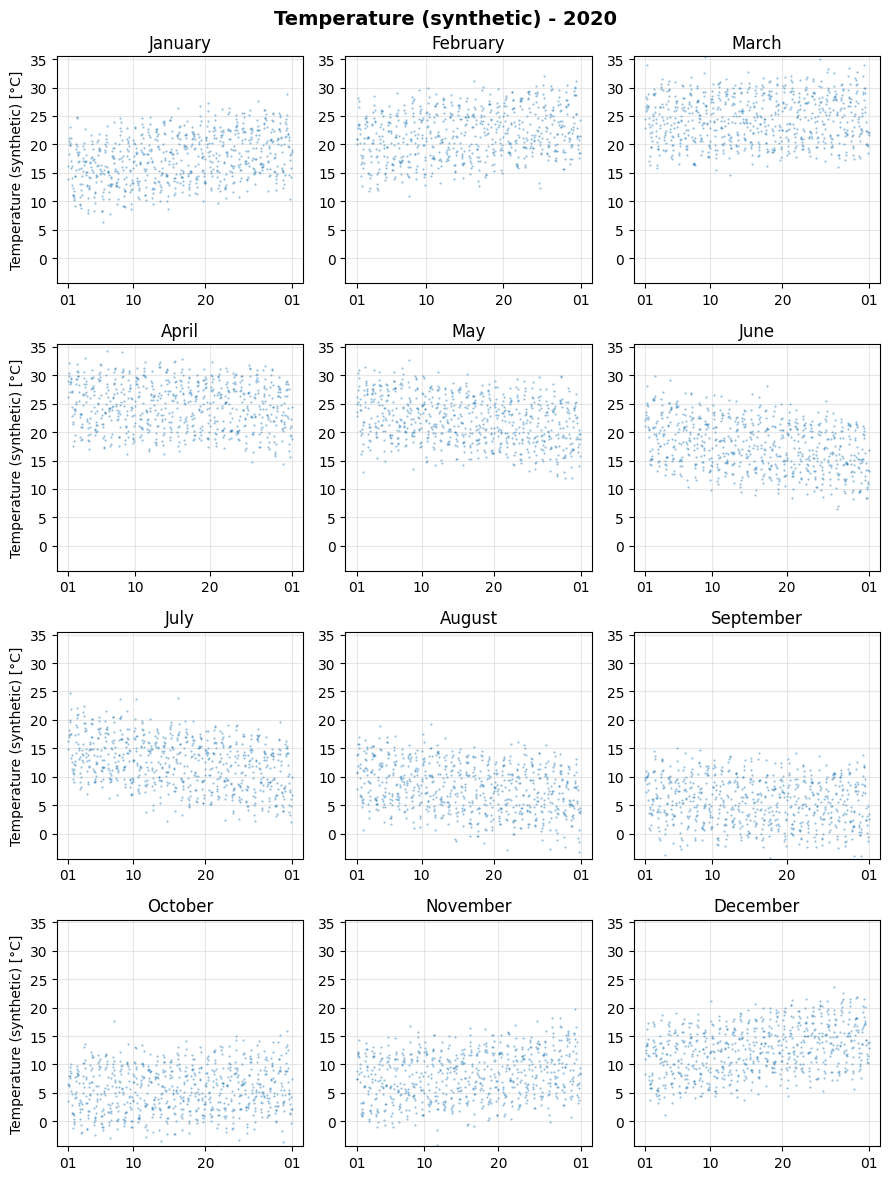

In [11]:

# Create synthetic sub-daily temperature data for 2020
dates = pd.date_range('2020-01-01', '2020-12-31 23:00', freq='h')
synthetic_temp = 15 + 10 * np.sin(2 * np.pi * np.arange(len(dates)) / (24*365)) + \
                 5 * np.sin(2 * np.pi * np.arange(len(dates)) / 24) + \
                 np.random.randn(len(dates)) * 2

subdaily_df = pd.DataFrame({
    'datetime': dates,
    'value': synthetic_temp
})

# Plot sub-daily data inline
plot_subdaily(
    data=subdaily_df,
    datetime_col='datetime',
    value_col='value',
    var_name='Temperature (synthetic)',
    units='°C',
    year=2020,
    fixed_ylim=True,
    show=True,
    marker='.',
    markersize=1,
    linestyle='',
    alpha=0.5
)


## 6. List all generated PDFs

In [12]:
from pathlib import Path

qc_dir = Path('notebooks/data/qc')
if qc_dir.exists():
    pdf_files = sorted(qc_dir.glob('*.pdf'))
    print(f"\n📁 Generated QC plots ({len(pdf_files)} files):\n")
    for pdf in pdf_files:
        size_kb = pdf.stat().st_size / 1024
        print(f"  • {pdf.name:50s} ({size_kb:6.1f} KB)")
else:
    print("QC directory not found")


📁 Generated QC plots (5 files):

  • climatic_outliers_boxplot_power_station_Tn.pdf     (  10.8 KB)
  • climatic_outliers_boxplot_power_station_Tx.pdf     (  11.6 KB)
  • climatic_outliers_boxplot_power_station_rr.pdf     (  15.1 KB)
  • daily_TMAX.pdf                                     (  33.1 KB)
  • decimals_TMAX.pdf                                  (  18.0 KB)
